Setup Environment And Import Library

In [ ]:
!pip install tensorflow opencv-python scikit-learn tqdm matplotlib

In [12]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


CPU Optimized (If you train with CPU)

In [13]:
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

Dataset

In [14]:
DATASET_PATH = r"C:\Iris Recognition\CASIA-Iris-Thousand"

IMG_SIZE = 64

Load Dataset

In [8]:
images = []
labels = []

persons = sorted(os.listdir(DATASET_PATH))

for label, person in enumerate(tqdm(persons)):

    person_path = os.path.join(DATASET_PATH, person)

    if not os.path.isdir(person_path):
        continue

    for eye in ["L", "R"]:

        eye_path = os.path.join(person_path, eye)

        if not os.path.isdir(eye_path):
            continue

        for img_name in os.listdir(eye_path):

            img_path = os.path.join(eye_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            images.append(img)
            labels.append(label)

images = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
labels = np.array(labels)

print("Images:", images.shape)
print("Labels:", labels.shape)

100%|██████████| 1000/1000 [04:12<00:00,  3.97it/s]


Images: (20000, 64, 64, 1)
Labels: (20000,)


Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16000, 64, 64, 1)
Test: (4000, 64, 64, 1)


Data Augmentation

In [16]:
datagen = ImageDataGenerator(

    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05

)

datagen.fit(X_train)

Build CNN Model

In [17]:
num_classes = len(np.unique(labels))

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(num_classes,activation='softmax')

])

model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │       257,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,530,472 (5.84 MB)

 Trainable params: 1,530,024 (5.84 MB)

 Non-trainable params: 448 (1.75 KB)

Compile Model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │       257,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,530,472 (5.84 MB)

 Trainable params: 1,530,024 (5.84 MB)

 Non-trainable params: 448 (1.75 KB)

Training Callbacks

In [19]:
early_stop = EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=0.00001

)

Training Model

In [20]:
history = model.fit(

    datagen.flow(X_train, y_train, batch_size=64),

    epochs=100,

    validation_data=(X_test, y_test),

    callbacks=[early_stop, reduce_lr]

)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.0013 - loss: 6.9415 - val_accuracy: 5.0000e-04 - val_loss: 10.2844 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.0018 - loss: 6.9054 - val_accuracy: 0.0015 - val_loss: 6.9752 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.0022 - loss: 6.8986 - val_accuracy: 7.5000e-04 - val_loss: 6.9008 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.0026 - loss: 6.8953 - val_accuracy: 0.0015 - val_loss: 6.9074 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.0027 - loss: 6.8863 - val_accuracy: 0.0012 - val_loss: 6.9102 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step - accuracy: 0.0036 - loss: 6.8748 - val_accuracy: 0.0010 - val_loss: 6.8940 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step

Training Graph

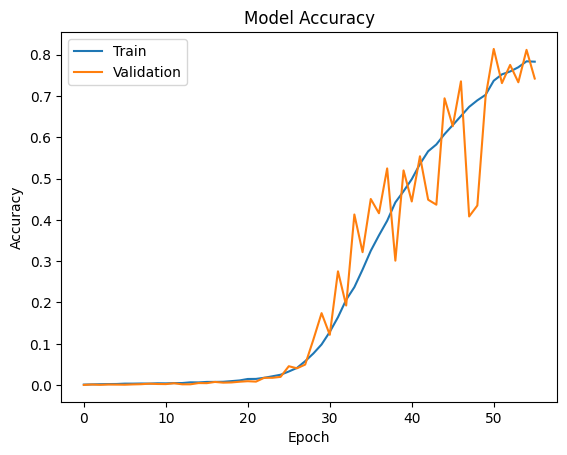

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

Evaluate Model

In [22]:
loss, acc = model.evaluate(X_test, y_test)

print("Test accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8138 - loss: 1.0097
Test accuracy: 0.8137500286102295


Save Model

In [23]:
model.save("IRISRecognizer.h5")

print("Model saved successfully!")

Model saved successfully!


Prediction Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted: 532
Actual: 532


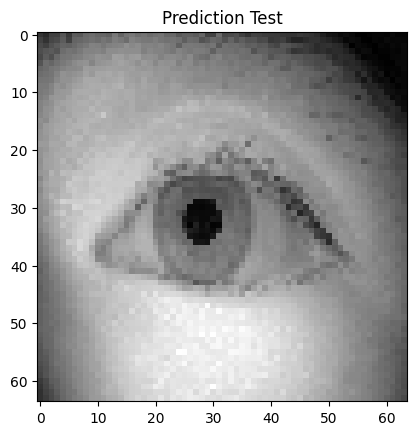

In [24]:
index = 0

sample = X_test[index]

prediction = model.predict(sample.reshape(1,64,64,1))

predicted_label = np.argmax(prediction)

print("Predicted:", predicted_label)
print("Actual:", y_test[index])

plt.imshow(sample.reshape(64,64), cmap="gray")
plt.title("Prediction Test")
plt.show()